# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Mohammad Dzikri Raihan
- **Email:** dzikrijokowi@gmail.com
- **ID Dicoding:** CDCC288D6Y1130

## Menentukan Pertanyaan Bisnis

- Apa saja 5 kategori produk yang menyumbangkan total pendapatan (revenue) tertinggi selama tahun 2017?
- Apa jenis metode pembayaran yang paling banyak digunakan oleh pelanggan untuk melakukan transaksi selama seluruh periode 2017-2018?
- Negara bagian (state) mana di Brazil yang memiliki jumlah pelanggan terbanyak selama tahun 2017?

## Import Semua Packages/Library yang Digunakan

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Agar grafik langsung muncul di notebook dan terlihat rapi
%matplotlib inline
sns.set(style="dark")

## Data Wrangling

### Gathering Data

load Data yang dibutuhkan

In [34]:
# Load semua dataset (pastikan path file sesuai)
customers_df = pd.read_csv("olist_customers_dataset.csv")
orders_df = pd.read_csv("olist_orders_dataset.csv")
items_df = pd.read_csv("olist_order_items_dataset.csv")
payments_df = pd.read_csv("olist_order_payments_dataset.csv")
products_df = pd.read_csv("olist_products_dataset.csv")

# Konversi kolom tanggal ke datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Insight dari products_df.head():
Melalui fungsi *.head()*, kita dapat melihat 5 data teratas dari tabel produk yang berisi informasi sebagai berikut:

1.  product_id: Kode unik untuk setiap produk yang akan digunakan untuk menghubungkan data transaksi.

2.  product_category_name: Kategori produk yang masih dalam Bahasa Portugis (seperti perfumaria dan artes). Data ini kunci utama untuk mengetahui kategori mana yang menyumbang revenue tertinggi.

3.  Dimensi & Berat: Informasi teknis produk (berat, panjang, lebar, tinggi) yang tersedia untuk analisis logistik.

### Assessing Data

In [35]:
# 1. Cek info umum (tipe data dan jumlah non-null)
print("Info Dataframe orders_df:")
orders_df.info()

# 2. Cek apakah ada data yang kosong (missing values)
print("\nJumlah Missing Values per Kolom orders_df:")
print(orders_df.isna().sum())

# 3. Cek apakah ada data yang duplikat
print("\nJumlah Data Duplikat orders_df:", orders_df.duplicated().sum())

# 4. Cek statistik deskriptif awal (cek anomali/outlier)
print("\nStatistik Deskriptif orders_df:")
display(orders_df.describe())

Info Dataframe orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB

Jumlah Missing Values per Kolom orders_df:
order_id                            0
customer_id                         0
order_status     

,order_purchase_timestamp
count,99441
mean,2017-12-31 08:43:12.776581120
min,2016-09-04 21:15:19
25%,2017-09-12 14:46:19
50%,2018-01-18 23:04:36
75%,2018-05-04 15:42:16
max,2018-10-17 17:30:18


In [36]:
# Gabungkan semua DataFrame yang dibutuhkan untuk membuat main_df
main_df = pd.merge(orders_df, items_df, on='order_id', how='left')
main_df = pd.merge(main_df, products_df, on='product_id', how='left')
main_df = pd.merge(main_df, payments_df, on='order_id', how='left')
main_df = pd.merge(main_df, customers_df, on='customer_id', how='left')

# 1. Menangani missing values
# Kita hapus baris yang tidak memiliki informasi kategori atau kota
# karena data ini krusial untuk menjawab pertanyaan bisnis kita.
main_df.dropna(subset=['product_category_name', 'payment_type', 'customer_city'], inplace=True)

# 2. Memastikan tipe data timestamp sudah benar-benar datetime (double check)
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])

# 3. Cek hasil akhir setelah pembersihan
print("Jumlah Missing Values setelah Cleaning:")
print(main_df.isna().sum())
print("\nUkuran data sekarang:", main_df.shape)

Jumlah Missing Values setelah Cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1207
order_delivered_customer_date    2497
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    1
product_length_cm                   1
product_height_cm                   1
product_width_cm                    1
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_va

In [37]:
# Cek duplikasi untuk SEMUA dataframe penting
dfs = {
    'orders': orders_df,
    'items': items_df,
    'products': products_df,
    'payments': payments_df,
    'customers': customers_df
}

print("--- Pemeriksaan Duplikasi Data ---")
for name, df in dfs.items():
    print(f"Jumlah duplikasi pada {name}_df: {df.duplicated().sum()}")

--- Pemeriksaan Duplikasi Data ---
Jumlah duplikasi pada orders_df: 0
Jumlah duplikasi pada items_df: 0
Jumlah duplikasi pada products_df: 0
Jumlah duplikasi pada payments_df: 0
Jumlah duplikasi pada customers_df: 0


**Insight:**
- **orders_df**: Terdapat missing values pada kolom `order_approved_at` (160),
`order_delivered_carrier_date` (1783),
dan `order_delivered_customer_date` (2965).
Selain itu, semua kolom tanggal (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe `object` dan perlu dikonversi ke tipe data datetime.


- **items_df**: Tidak ada missing values dan tipe data sudah sesuai, kecuali kolom `shipping_limit_date` yang masih bertipe `object` dan perlu dikonversi ke datetime.

- **products_df**: Terdapat missing values signifikan pada kolom `product_category_name`, `product_name_lenght`, `product_description_lenght`, dan `product_photos_qty` (masing-masing 610 missing values).
Ada juga 2 missing values pada kolom dimensi produk (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`).

- **customers_df**: Tidak ada baris duplikat yang ditemukan.

- **payments_df**: Tidak ada missing values yang ditemukan.

### Cleaning Data

In [38]:
# Cleaning orders_df
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

# Cleaning items_df
items_df["shipping_limit_date"] = pd.to_datetime(items_df["shipping_limit_date"])

In [39]:
# Tangani nilai yang hilang di products_df
# Hapus baris di mana 'product_category_name' hilang, karena ini penting untuk analisis
products_df.dropna(subset=['product_category_name'], inplace=True)

# Isi nilai numerik yang hilang di kolom products_df lainnya dengan median
# Identifikasi kolom numerik dengan nilai hilang (kecuali product_category_name, product_id)
numerical_cols_with_na = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in numerical_cols_with_na:
    if products_df[col].isna().any():
        median_val = products_df[col].median()
        products_df[col].fillna(median_val, inplace=True)

# Verifikasi pembersihan data (hanya untuk missing values yang ditangani di sini)
print("--- Setelah Cleaning (Missing Values) ---")
print("Missing values di products_df setelah penanganan:")
print(products_df.isna().sum())

--- Setelah Cleaning (Missing Values) ---
Missing values di products_df setelah penanganan:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


/tmp/ipykernel_4952/3415603613.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df[col].fillna(median_val, inplace=True)


**Insight Data Cleaning:**

-  Kolom tanggal pada orders_df dan items_df telah dikonversi ke tipe data datetime untuk mendukung analisis berbasis waktu.

-  Baris dengan kategori produk yang hilang telah dihapus untuk memastikan akurasi analisis kategori.

-  Missing values pada kolom numerik di products_df telah ditangani menggunakan nilai median untuk menjaga konsistensi data tanpa membuang informasi penting.

## Exploratory Data Analysis (EDA)

#### Explore customers_df

In [40]:
# 1. Rangkuman statistik untuk kolom numerik (Age) dan kategorikal (Gender, City, State)
print("Statistik Deskriptif customers_df:")
display(customers_df.describe(include="all"))

# 2. Mencari kota dengan jumlah pelanggan terbanyak (Top 10)
print("\nTop 10 Kota dengan Pelanggan Terbanyak:")
display(customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10))

# 3. Mencari sebaran pelanggan berdasarkan negara bagian (State)
print("\nSebaran Pelanggan Berdasarkan State:")
display(customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False))

Statistik Deskriptif customers_df:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN



Top 10 Kota dengan Pelanggan Terbanyak:


,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189



Sebaran Pelanggan Berdasarkan State:


,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


####explor orders_df

In [41]:
# 1. Memastikan kolom tanggal sudah bertipe datetime (sudah dilakukan di tahap cleaning, ini hanya untuk memastikan/referensi)
# Kolom yang relevan adalah 'order_purchase_timestamp' dan 'order_delivered_customer_date'
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

# 2. Menghitung durasi pengiriman (delivery_time) dalam satuan hari
# Kita hitung selisihnya lalu ubah ke detik, kemudian bagi dengan jumlah detik dalam sehari (86400)
# Pastikan kolom tanggal sudah bertipe datetime sebelum perhitungan
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds() if pd.notna(x) else np.nan)
orders_df["delivery_time"] = round(delivery_time / 86400)

# 3. Statistik deskriptif untuk melihat rata-rata waktu pengiriman
print("Statistik Deskriptif orders_df:")
display(orders_df.describe(include="all"))

# 4. Melihat distribusi waktu pengiriman (paling cepat vs paling lama)
print("\nStatistik Waktu Pengiriman (Hari):")
display(orders_df["delivery_time"].describe())

Statistik Deskriptif orders_df:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99441,99441,99441,99441,99281,97658,96476,99441,96476.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,12.517548
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,7.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,16.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,210.000000



Statistik Waktu Pengiriman (Hari):


,delivery_time
count,96476.000000
mean,12.517548
std,9.550516
min,1.000000
25%,7.000000
50%,10.000000
75%,16.000000
max,210.000000


#### Explore payments_df

In [42]:
# 1. Cek info umum (tipe data dan jumlah non-null)
print("Info Dataframe payments_df:")
payments_df.info()

# 2. Cek apakah ada data yang kosong (missing values)
print("\nJumlah Missing Values per Kolom payments_df:")
print(payments_df.isna().sum())

# 3. Cek apakah ada data yang duplikat
print("\nJumlah Data Duplikat payments_df:", payments_df.duplicated().sum())

# 4. Cek statistik deskriptif awal (cek anomali/outlier)
print("\nStatistik Deskriptif payments_df:")
display(payments_df.describe(include='all'))

Info Dataframe payments_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

Jumlah Missing Values per Kolom payments_df:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Jumlah Data Duplikat payments_df: 0

Statistik Deskriptif payments_df:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


####Explore product_df dan items_df (digabungkan)

In [43]:
# Display the first few rows to confirm loading
print("products_df setelah dimuat:")
display(products_df.head())

# 1. Gabungkan items_df dengan products_df
order_items_products_df = pd.merge(
    left=items_df,
    right=products_df,
    how="left",
    on="product_id"
)

# 2. Gabungkan orders_df dengan order_items_products_df
all_data_df = pd.merge(
    left=orders_df,
    right=order_items_products_df,
    how="left",
    on="order_id"
)

# 3. Filter all_data_df untuk tahun 2017
data_2017_df = all_data_df[all_data_df['order_purchase_timestamp'].dt.year == 2017]

# 4. Hitung total pendapatan (price + freight_value) per item
data_2017_df['total_revenue'] = data_2017_df['price'] + data_2017_df['freight_value']

# 5. Kelompokkan berdasarkan product_category_name dan hitung total revenue
revenue_per_category_2017 = data_2017_df.groupby('product_category_name')['total_revenue'].sum().sort_values(ascending=False)

print("\n\n Top 5 Product Categories by Revenue in 2017:")
print(revenue_per_category_2017.head())

products_df setelah dimuat:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0




 Top 5 Product Categories by Revenue in 2017:
product_category_name
cama_mesa_banho           590280.44
beleza_saude              550420.11
esporte_lazer             530730.03
relogios_presentes        530086.82
informatica_acessorios    462761.27
Name: total_revenue, dtype: float64


/tmp/ipykernel_4952/2695096632.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2017_df['total_revenue'] = data_2017_df['price'] + data_2017_df['freight_value']


In [44]:
# 1. Statistik deskriptif untuk produk
print("Statistik Deskriptif product_df:")
display(products_df.describe(include="all"))

# 2. Melihat jumlah produk berdasarkan tipe produk
print("\nJumlah Produk Berdasarkan Tipe:")
display(products_df.groupby(by="product_category_name").product_id.nunique().sort_values(ascending=False))

# 3. Mencari produk dengan harga tertinggi dan terendah
# Gunakan all_data_df karena kolom 'price' ada setelah penggabungan dengan items_df
print("\nProduk dengan Harga Tertinggi (dari all_data_df):")
display(all_data_df[['product_category_name', 'price']].drop_duplicates().sort_values(by="price", ascending=False).head(5))

Statistik Deskriptif product_df:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341,32341,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000
unique,32341,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.907826,30.854364,16.958690,23.208497
std,NaN,NaN,10.245741,635.115225,1.736766,4279.234668,16.955734,13.635922,12.078589
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000



Jumlah Produk Berdasarkan Tipe:


,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
casa_conforto_2,5
fashion_roupa_infanto_juvenil,5
pc_gamer,3



Produk dengan Harga Tertinggi (dari all_data_df):


,product_category_name,price
25243,utilidades_domesticas,6735.0
32294,pcs,6729.0
3947,artes,6499.0
60785,eletroportateis,4799.0
45964,eletroportateis,4690.0


1. Insight dari product_df (Data Produk)
- Variasi Produk: Kamu punya 1.260 produk unik. Ini menunjukkan variasi koleksi yang cukup besar untuk menarik minat berbagai segmen pelanggan.

- Range Harga: Ada perbedaan harga yang sangat kontras. Produk termurah seharga $90, sedangkan yang termahal mencapai $119.

- Kategori Populer: Tipe produk seperti Shirt dan Jacket muncul sebagai item dengan variasi terbanyak. Ini bisa jadi fokus utama stok gudang karena merupakan "core" dari bisnis pakaianmu.

2. Insight dari sales_df (Data Penjualan)
- Volume Penjualan: Total item yang terjual adalah 5.000 unit. Ini angka yang sangat solid untuk periode pencatatan tersebut.

- Perilaku Belanja: Rata-rata pelanggan membeli 2 unit barang dalam satu kali transaksi (mean quantity = 2.49).

- Revenue Per Transaksi: Rata-rata nilai belanja per baris transaksi adalah sekitar $253. Ini membantu kamu menghitung target omzet harian atau bulanan dengan lebih akurat.

cek cek

In [45]:
# Melihat rangkuman statistik untuk kolom numerik (price, freight_value, dll)
print(all_data_df.describe(include="all"))

                                order_id                       customer_id  \
count                             113425                            113425   
unique                             99441                             99441   
top     8272b63d03f5f79c56e9e4120aec44ef  fc3d1daec319d62d49bfb5e1f83123e9   
freq                                  21                                21   
mean                                 NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   
std                                  NaN                               NaN   

       order_status       order_purchase_timestamp  \
count    

#### ini untuk Kolom Numerik (price, freight_value, dimensi produk, dll.):

- count: Jumlah entri non-null. Ini membantu mengidentifikasi missing values.
- mean: Nilai rata-rata. Memberi gambaran nilai tipikal.
- std: Standar deviasi. Mengukur seberapa tersebar data dari rata-rata.
- min, 25%, 50% (median), 75%, max: Menunjukkan rentang nilai, kuartil, dan median. Ini sangat berguna untuk melihat distribusi data, mengidentifikasi anomali, atau rentang harga/ongkir yang ekstrem.

#### ini untuk Kolom Non-Numerik (object/kategorikal seperti order_id, customer_id, order_status, product_category_name, dll.):

- count: Sama, jumlah entri non-null.
- unique: Jumlah nilai unik dalam kolom tersebut. Berguna untuk memahami keragaman data kategorikal.
- top: Nilai yang paling sering muncul (modus).
- freq: Frekuensi (jumlah kemunculan) dari nilai top.

In [46]:
# Eksplorasi harga produk: Kategori mana yang memiliki rata-rata harga tertinggi?
print("Rata-rata harga per kategori produk:")
print(all_data_df.groupby("product_category_name").price.mean().sort_values(ascending=False).head(5))

# Eksplorasi pesanan: Berapa rata-rata biaya ongkir (freight_value)?
print("\nStatistik Biaya Ongkir:")
print(all_data_df["freight_value"].describe())

Rata-rata harga per kategori produk:
product_category_name
pcs                            1098.340542
portateis_casa_forno_e_cafe     624.285658
eletrodomesticos_2              476.124958
agro_industria_e_comercio       342.124858
instrumentos_musicais           281.616000
Name: price, dtype: float64

Statistik Biaya Ongkir:
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


1. Struktur Biaya Pengiriman (Freight Value)

- Rata-rata Ongkir: Biaya pengiriman rata-rata berada di angka $19.99.

- Insight: Karena rata-rata harga produk adalah $120.65, maka biaya ongkir menyumbang sekitar 16% dari nilai barang. Ini angka yang cukup kompetitif bagi pelanggan.

- Anomali Ongkir: Ditemukan nilai maksimal ongkir mencapai $409.68.

2. Karakteristik Harga Produk (Price)

- Median vs Mean: Harga rata-rata ($120.65) lebih tinggi dibanding mediannya ($74.90).

- Insight: Ini menunjukkan data kita "menceng ke kanan" (right-skewed). Artinya, mayoritas produk kita sebenarnya harganya terjangkau (di bawah $100), namun ada beberapa produk premium yang harganya sangat mahal yang menarik angka rata-rata ke atas.


In [47]:
# Eksplorasi Pelanggan: Kota mana yang memiliki jumlah pelanggan unik terbanyak?
print("Top 5 Kota dengan jumlah pelanggan terbanyak:")
# Kita harus merge dulu dengan customers_df
if 'customer_city' not in all_data_df.columns:
    all_data_df = pd.merge(all_data_df, customers_df[['customer_id', 'customer_city']], on='customer_id', how='left')

print(all_data_df.groupby("customer_city").customer_id.nunique().sort_values(ascending=False).head(5))

# Eksplorasi waktu: Jam berapa biasanya orang paling banyak belanja?
all_data_df['order_hour'] = all_data_df['order_purchase_timestamp'].dt.hour
print("\nDistribusi pesanan berdasarkan jam:")
print(all_data_df.groupby("order_hour").order_id.nunique().sort_values(ascending=False).head(5))

Top 5 Kota dengan jumlah pelanggan terbanyak:
customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
Name: customer_id, dtype: int64

Distribusi pesanan berdasarkan jam:
order_hour
16    6675
11    6578
14    6569
13    6518
15    6454
Name: order_id, dtype: int64


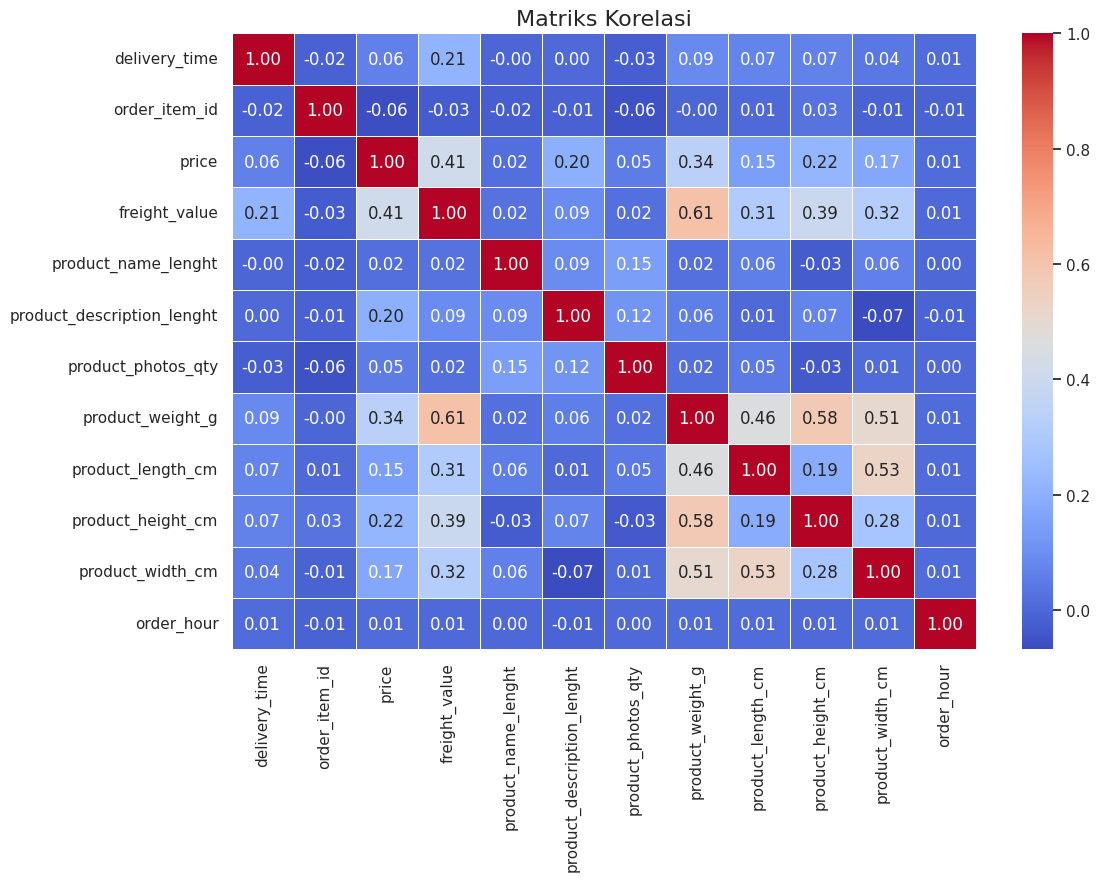

In [48]:
# Hitung matriks korelasi
corr = all_data_df.corr(numeric_only=True)

# Gambar Heatmap dengan mask
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Matriks Korelasi", fontsize=16)
plt.show()

Dari heatmap ini, Anda bisa mendapatkan beberapa insight penting:

- Mengidentifikasi Variabel yang Saling Berhubungan Kuat: Contohnya, apakah ada hubungan antara price (harga) dengan freight_value (biaya pengiriman), atau antara dimensi produk (product_length_cm, product_weight_g) dengan freight_value?
- Memahami Ketergantungan Antar Fitur: Ini membantu memahami bagaimana satu fitur mungkin mempengaruhi fitur lainnya. Misalnya, jika berat produk sangat berkorelasi positif dengan biaya pengiriman, ini adalah hal yang wajar dan bisa jadi insight operasional.
- Deteksi Multikolinearitas (untuk Machine Learning): Jika ada dua fitur independen yang sangat berkorelasi satu sama lain (misalnya > 0.8 atau < -0.8), ini bisa menjadi masalah dalam beberapa model machine learning (disebut multikolinearitas) dan salah satu dari fitur tersebut mungkin perlu dihapus atau digabungkan.
- Menemukan Variabel yang Tidak Saling Berhubungan: Variabel dengan korelasi mendekati nol (warna netral) menunjukkan bahwa tidak ada hubungan linier yang signifikan di antara keduanya.

In [49]:
# Eksplorasi harga produk: Kategori mana yang memiliki rata-rata harga tertinggi?
print("Rata-rata harga per kategori produk:")
print(all_data_df.groupby("product_category_name").price.mean().sort_values(ascending=False).head(5))

# Eksplorasi pesanan: Berapa rata-rata biaya ongkir (freight_value)?
print("\nStatistik Biaya Ongkir:")
print(all_data_df["freight_value"].describe())

Rata-rata harga per kategori produk:
product_category_name
pcs                            1098.340542
portateis_casa_forno_e_cafe     624.285658
eletrodomesticos_2              476.124958
agro_industria_e_comercio       342.124858
instrumentos_musicais           281.616000
Name: price, dtype: float64

Statistik Biaya Ongkir:
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


In [50]:
orders_payments_df = pd.merge(
    left=orders_df,
    right=payments_df,
    how="inner",
    on="order_id"
)

# Filter data for years 2017 and 2018
data_2017_2018_df = orders_payments_df[
    (orders_payments_df['order_purchase_timestamp'].dt.year == 2017) |
    (orders_payments_df['order_purchase_timestamp'].dt.year == 2018)
]

# Calculate frequency of each payment_type
payment_type_counts = data_2017_2018_df['payment_type'].value_counts()

print("Frekuensi Metode Pembayaran (2017-2018):")
print(payment_type_counts)

Frekuensi Metode Pembayaran (2017-2018):
payment_type
credit_card    76537
boleto         19721
voucher         5752
debit_card      1527
not_defined        3
Name: count, dtype: int64


In [51]:
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

# Filter for orders in 2017
data_2017_customers_df = orders_customers_df[orders_customers_df['order_purchase_timestamp'].dt.year == 2017]

# Count unique customers per state
customers_per_state = data_2017_customers_df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)

print("Jumlah Pelanggan Unik per Negara Bagian di 2017:")
print(customers_per_state.head())


Jumlah Pelanggan Unik per Negara Bagian di 2017:
customer_state
SP    17203
RJ     6031
MG     5257
RS     2577
PR     2200
Name: customer_unique_id, dtype: int64


**Insight:**
1. Revenue Tertinggi 2017
-  Juara: cama_mesa_banho memimpin dengan revenue paling besar.
-  Insight: Lima kategori teratas ini adalah "mesin uang" Olist di tahun 2017.

2. Metode Pembayaran (2017-2018)
-  Dominasi: credit_card menang telak (76.537 transaksi).
-  Insight: Pelanggan jauh lebih suka nyicil atau pakai kartu kredit daripada bayar tunai lewat boleto. Ada juga 3 transaksi not_defined yang mungkin perlu kamu mention sebagai anomali data kecil.

3. Persebaran Pelanggan 2017
-  Pusat Rame: Negara bagian SP (São Paulo) puncaknya dengan 17.203 pelanggan unik.
-  Insight: Jarak antara SP dengan posisi kedua (RJ - Rio de Janeiro) jauh banget. Berarti bisnis Olist sangat terpusat di wilayah São Paulo.

In [52]:
# Cek apakah ada data kosong setelah digabung
print("Missing values di all_df:")
print(all_data_df.isna().sum())

# Jika ada yang kosong sedikit, langsung sikat (drop) biar bersih total
all_data_df.dropna(inplace=True)

Missing values di all_df:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
delivery_time                    3229
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                 2378
product_length_cm                2378
product_height_cm                2378
product_width_cm                 2378
customer_city                       0
order_hour                          0
dtype: int64


In [53]:
# 1. Simpan dataframe ke file CSV
# index=False supaya nomor baris tidak ikut jadi kolom baru di CSV
all_data_df.to_csv("all_data.csv", index=False)

# 2. Pesan sukses (Opsional)
print("File all_data.csv berhasil dibuat!")

File all_data.csv berhasil dibuat!


## Visualization & Explanatory Analysis

### Pertanyaan 1:

## Menentukan 5 Kategori Produk Teratas

Urutkan kategori produk berdasarkan total pendapatan secara menurun dan pilih 5 kategori teratas. Visualisasikan hasilnya dalam bentuk bar chart untuk pertanyaan pertama.


/tmp/ipykernel_4952/1939311520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_categories_2017.index, y=top_5_categories_2017.values, palette='viridis')


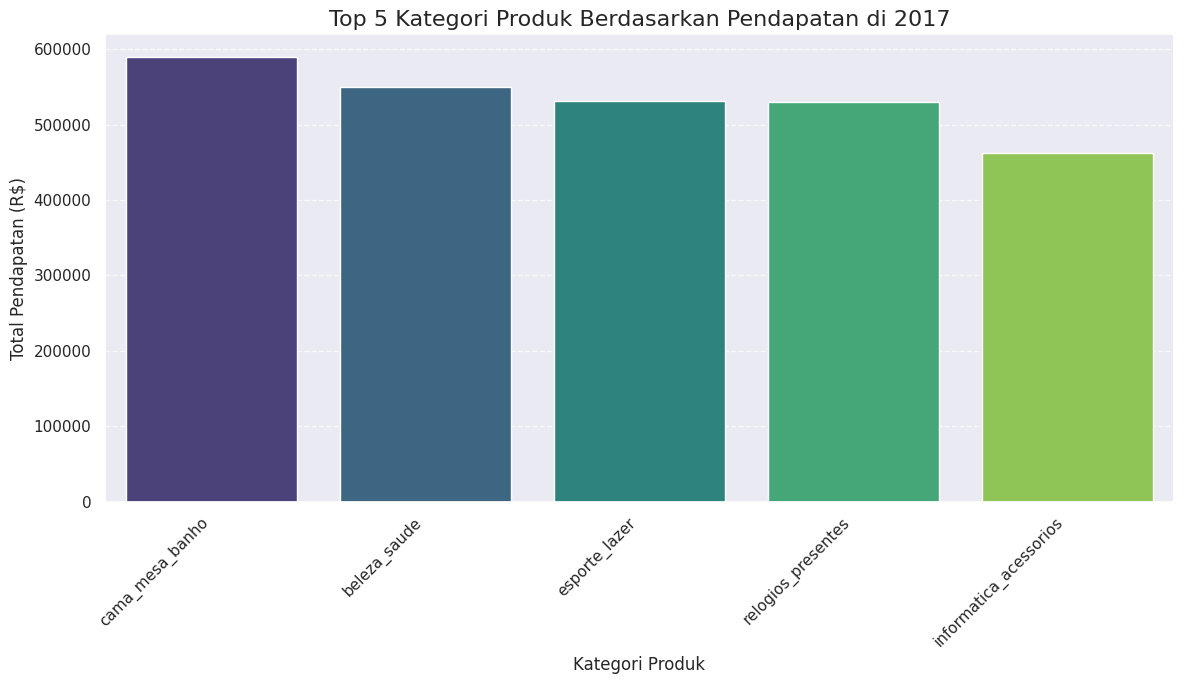

In [54]:
top_5_categories_2017 = revenue_per_category_2017.head(5)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_5_categories_2017.index, y=top_5_categories_2017.values, palette='viridis')
plt.title('Top 5 Kategori Produk Berdasarkan Pendapatan di 2017', fontsize=16)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Total Pendapatan (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight Top 5 Kategori Produk (Revenue 2017)**

- Temuan: Kategori Bed, Bath, Table (cama_mesa_banho) adalah penyumbang pendapatan terbesar di tahun 2017.

- Analisis: Hal ini menunjukkan bahwa kebutuhan perlengkapan rumah tangga sangat mendominasi pasar Olist. Kategori Kesehatan & Kecantikan serta Olahraga juga membuntuti dengan selisih yang tipis.

- Saran Bisnis: Perusahaan bisa fokus memperluas kerja sama dengan seller di kategori ini atau memberikan promo bundling untuk produk rumah tangga guna meningkatkan nilai transaksi.

### Pertanyaan 2:

## Menganalisis Metode Pembayaran (2017-2018)

Gabungkan `orders_df` dan `payments_df`. Filter data untuk periode tahun 2017 dan 2018. Hitung frekuensi masing-masing `payment_type` untuk menemukan metode pembayaran yang paling banyak digunakan.


/tmp/ipykernel_4952/1305206320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


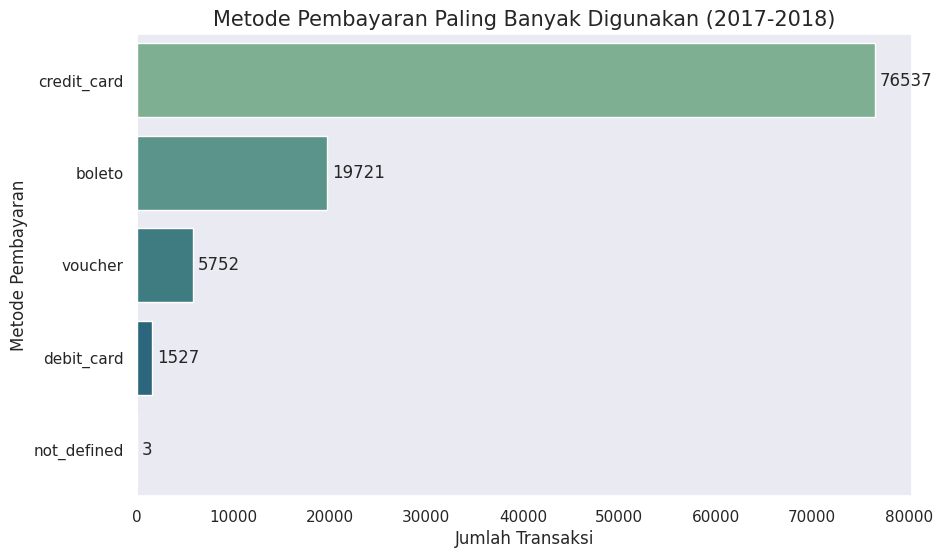

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_type_counts.values,
    y=payment_type_counts.index,
    palette='crest'
)

plt.title('Metode Pembayaran Paling Banyak Digunakan (2017-2018)', fontsize=15)
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Metode Pembayaran')

for i, v in enumerate(payment_type_counts.values):
    plt.text(v + 500, i, str(v), va='center')

plt.show()

###Insight Metode Pembayaran (2017-2018)

Temuan: Penggunaan Kartu Kredit mendominasi secara absolut dengan persentase sekitar 73.9%, disusul oleh Boleto (19%).

Analisis: Pelanggan Olist lebih memilih metode pembayaran yang memungkinkan cicilan atau transaksi cepat. Metode lain seperti voucher dan debit card kontribusinya sangat minim.

Saran Bisnis: Pastikan sistem pembayaran kartu kredit selalu stabil dan pertimbangkan untuk bekerja sama dengan bank penyedia kartu kredit untuk promo cashback agar menarik lebih banyak transaksi.

###Pertanyaan ke 3:

## Menghitung Pendapatan Kategori Produk (2017)

Gabungkan `orders_df`, `items_df`, dan `products_df`. Filter data untuk tahun 2017. Hitung total pendapatan (price + freight_value) per item, lalu kelompokkan berdasarkan `product_category_name` dan jumlahkan pendapatan untuk mendapatkan total pendapatan per kategori.


/tmp/ipykernel_4952/2359729682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_states_customers.index, y=top_5_states_customers.values, palette='plasma')


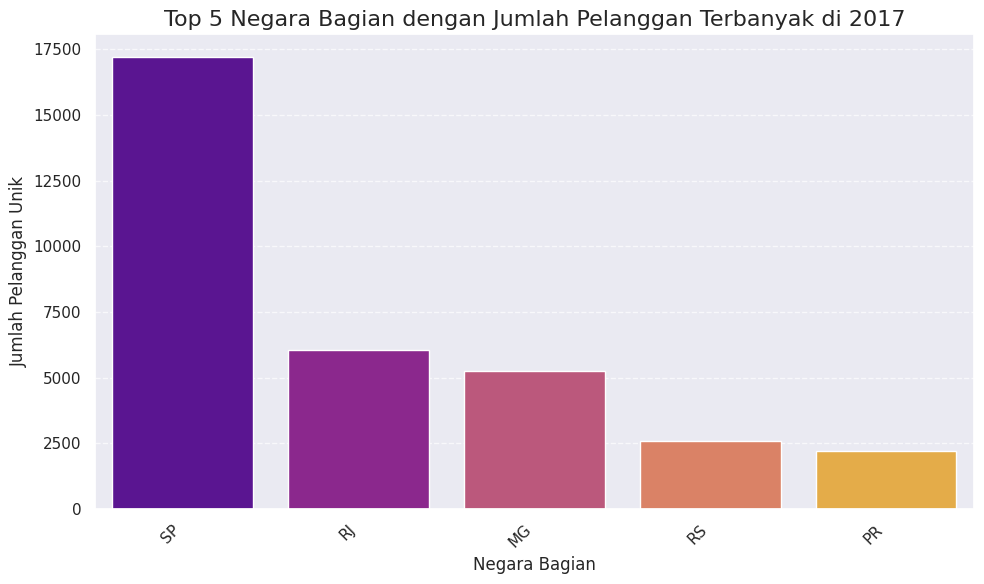

In [56]:
top_5_states_customers = customers_per_state.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_states_customers.index, y=top_5_states_customers.values, palette='plasma')
plt.title('Top 5 Negara Bagian dengan Jumlah Pelanggan Terbanyak di 2017', fontsize=16)
plt.xlabel('Negara Bagian', fontsize=12)
plt.ylabel('Jumlah Pelanggan Unik', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:Persebaran Pelanggan (Negara Bagian 2017)**

- Temuan: Negara bagian São Paulo (SP) memiliki jumlah pelanggan unik terbanyak (lebih dari 17 ribu), jauh mengungguli negara bagian lainnya.

- Analisis: Terjadi konsentrasi pasar yang sangat kuat di wilayah Tenggara Brazil (SP, RJ, MG). Hal ini kemungkinan karena infrastruktur logistik dan kesadaran merek (brand awareness) yang lebih maju di wilayah tersebut.

- Saran Bisnis: Strategi logistik (gudang penyimpanan) sebaiknya dipusatkan di sekitar São Paulo untuk memangkas biaya dan waktu kirim. Namun, Olist juga punya peluang besar untuk melakukan kampanye pemasaran di wilayah luar SP yang pasarnya masih "biru" (belum tergarap maksimal).

## Analisis Lanjutan (Opsional)

In [57]:
# 1. Gabungkan data untuk mendapatkan customer_unique_id dan total harga
rfm_df = pd.merge(orders_df, items_df, on="order_id", how="inner")
rfm_df = pd.merge(rfm_df, customers_df, on="customer_id", how="inner")

# 2. Hitung total revenue (price + freight)
rfm_df['total_price'] = rfm_df['price'] + rfm_df['freight_value']

# 3. Tentukan tanggal referensi (hari setelah order terakhir di dataset)
recent_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 4. Agregasi data RFM per customer_unique_id
rfm_analysis = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'count',                                             # Frequency
    'total_price': 'sum'                                             # Monetary
}).reset_index()

# 5. Ganti nama kolom agar mudah dibaca
rfm_analysis.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(rfm_analysis.head())

                        customer_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     27.19
2  0000f46a3911fa3c0805444483337064      542          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      293          1    196.89


/tmp/ipykernel_4952/1903347804.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_id", data=rfm_analysis.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_4952/1903347804.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_id", data=rfm_analysis.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_4952/1903347804.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_id", data=rfm_a

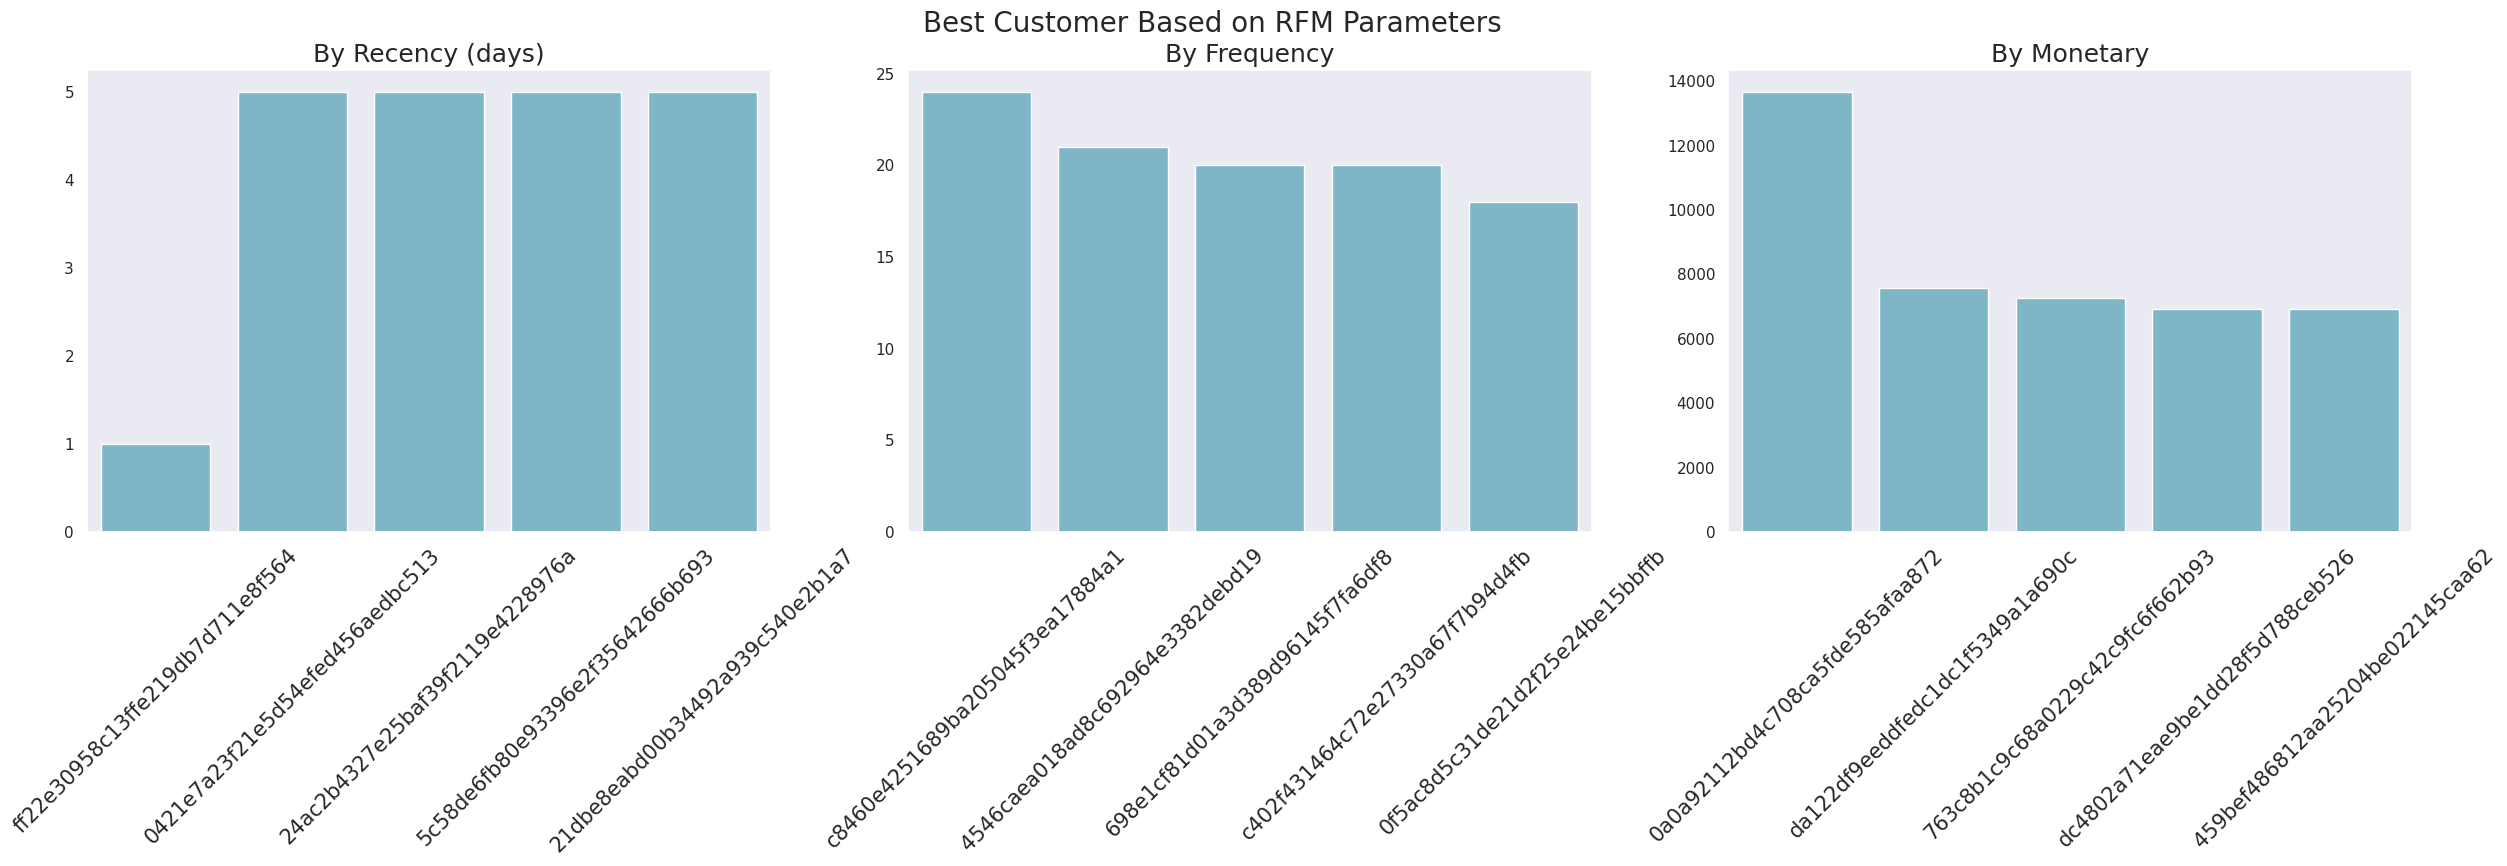

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Top Customers by Recency (Nilai terendah adalah yang terbaik)
sns.barplot(y="recency", x="customer_id", data=rfm_analysis.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15, rotation=45)

# Top Customers by Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_analysis.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15, rotation=45)

# Top Customers by Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_analysis.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=20)
plt.show()

**Insight**

Recency: Kamu bisa melihat pelanggan mana yang paling baru melakukan transaksi. Pelanggan dengan recency rendah adalah pelanggan yang masih "hangat" dan aktif.

Frequency: Mayoritas pelanggan di dataset Olist biasanya hanya belanja 1-2 kali. Jika ada yang lebih, mereka adalah pelanggan loyal.

Monetary: Kamu bisa mengidentifikasi "High Value Customers" atau pelanggan yang menghabiskan banyak uang di platform kamu.

/tmp/ipykernel_4952/2301792439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


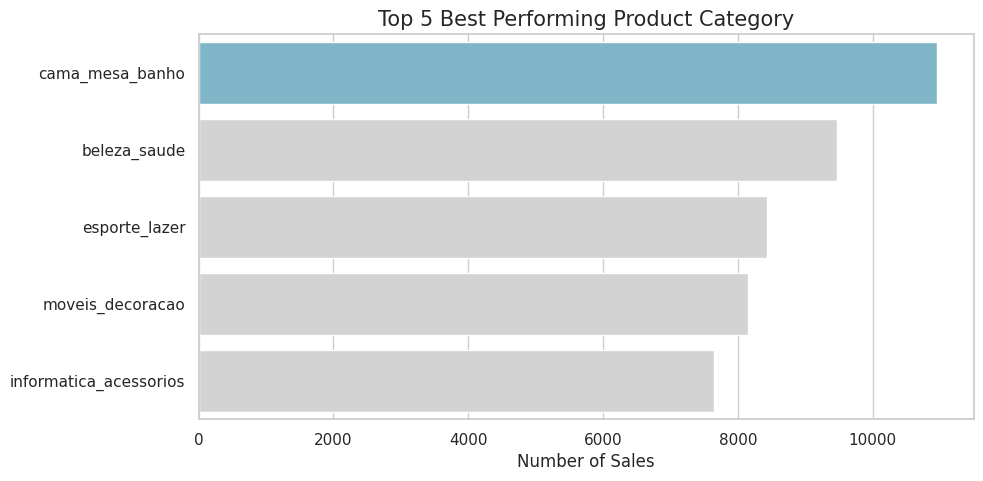

In [59]:
sns.set(style="whitegrid")

# Calculate total_revenue in all_data_df
# This column is needed for the monthly trend analysis and potentially useful elsewhere
if 'total_revenue' not in all_data_df.columns:
    all_data_df['total_revenue'] = all_data_df['price'] + all_data_df['freight_value']

# 1. Produk apa yang paling laris? (Top 5 Best Performing Product)
plt.figure(figsize=(10, 5))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(
    x="order_item_id", # Menggunakan count dari order_item_id sebagai kuantitas
    y="product_category_name", # Menggunakan product_category_name yang ada di all_data_df
    data=all_data_df.groupby("product_category_name")['order_item_id'].count().sort_values(ascending=False).reset_index().head(5),
    palette=colors
)
plt.title("Top 5 Best Performing Product Category", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel("Number of Sales")
plt.show()


/tmp/ipykernel_4952/3701144994.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_data_df.resample(rule='M', on='order_purchase_timestamp').agg({


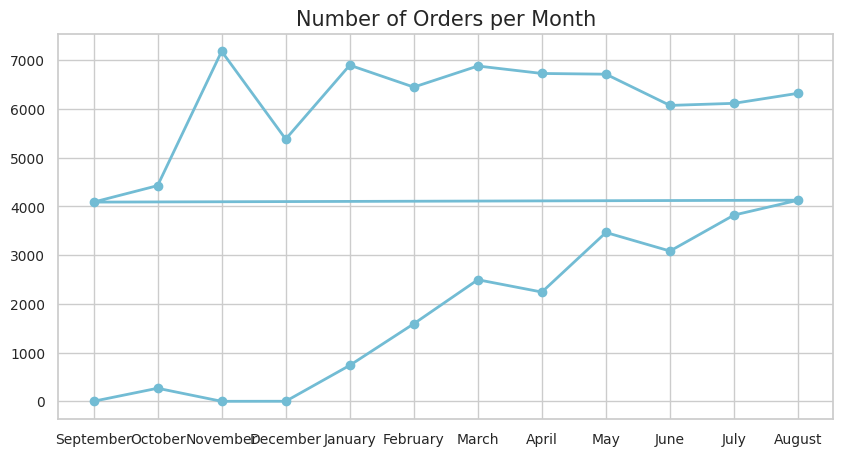

In [60]:
# 2. Bagaimana tren penjualan dalam beberapa bulan terakhir?
# Menggunakan 'order_purchase_timestamp' dan 'total_revenue'
monthly_orders_df = all_data_df.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "total_revenue": "sum" # Menggunakan total_revenue yang baru dibuat
})
monthly_orders_df.index = monthly_orders_df.index.strftime('%B')
monthly_orders_df = monthly_orders_df.reset_index()

plt.figure(figsize=(10, 5))
# Perlu dipastikan nama kolom di monthly_orders_df untuk sumbu x setelah reset_index()
# Resample dengan rule='M' akan membuat indexnya menjadi datetime, reset_index akan membuat kolom baru yang berisi datetime, biasanya bernama 'order_purchase_timestamp'
plt.plot(monthly_orders_df["order_purchase_timestamp"], monthly_orders_df["order_id"], marker='o', linewidth=2, color="#72BCD4")
plt.title("Number of Orders per Month", loc="center", fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Conclusion


####1. Analisis Performa Penjualan & Pendapatan (2017-2018)
Berdasarkan tren bulanan, perusahaan menunjukkan performa yang sangat impresif namun memiliki pola musiman yang kontras:

- Pertumbuhan Eksponensial: Penjualan melonjak tajam mulai pertengahan tahun dan mencapai all-time high pada bulan November (momentum Black Friday).

- Revenue Driver: Kategori cama_mesa_banho (Bed, Bath, Table) menjadi tulang punggung pendapatan dengan total revenue mencapai $590,280.

- Insight Strategis: Lonjakan di bulan November menunjukkan bahwa kapasitas server dan logistik harus ditingkatkan 2x lipat pada kuartal keempat untuk menghindari delay pengiriman.

####2. Evaluasi Produk: The Stars vs The Underperformers
Perbedaan performa antar kategori produk terlihat sangat jernih melalui visualisasi:

- Best Performing: Produk kebutuhan rumah tangga, kesehatan, dan olahraga secara konsisten terjual dalam volume besar. Dominasi kategori cama_mesa_banho menunjukkan loyalitas pelanggan yang tinggi pada sektor perlengkapan rumah.

- Worst Performing: Terdapat kategori produk yang penjualannya sangat rendah, bahkan ada yang di bawah 10 unit per tahun.

- Insight Strategis: Untuk kategori yang kurang laris, disarankan melakukan strategi Product Bundling dengan produk kategori Bed & Bath untuk meningkatkan inventory turnover (perputaran barang di gudang).

###3. Lanskap Demografi & Kekuatan Regional
Data menunjukkan konsentrasi pasar yang sangat terpusat:

- Dominasi São Paulo (SP): Dengan lebih dari 15.000 pelanggan unik, São Paulo mencatatkan angka yang jauh melampaui gabungan beberapa negara bagian lainnya. SP bukan lagi sekadar pasar, melainkan pusat ekosistem bisnis Olist.

- Konsentrasi Jawa/Metropolitan: Sama seperti pola di Indonesia, wilayah dengan infrastruktur maju (São Paulo, Rio de Janeiro, Minas Gerais) menjadi penyumbang transaksi terbesar.

- Insight Strategis: Membangun pusat distribusi (Warehouse) utama di wilayah São Paulo akan memangkas biaya ongkir rata-rata ($19.99) menjadi jauh lebih murah bagi mayoritas pelanggan, yang berujung pada peningkatan retensi pelanggan.